## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## Installing and Importing Necessary Libraries and Dependencies

In [2]:
# Install the llama-cpp-python package, which enables running LLaMA-based models (e.g., Mistral, LLaMA 2)
# locally using C++ backends for faster inference, especially with GGUF quantized models.
!pip install llama-cpp-python

In [44]:
# ----------------------------
# INSTALLING REQUIRED LIBRARIES
# ----------------------------

# Installiing all necessary libraries in one pip command to avoid version conflicts and ensure consistency.
# Includes libraries for:
# - Numerical computing (numpy)
# - LLM inference (llama-cpp-python)
# - HuggingFace Hub access
# - Data processing (pandas)
# - Token counting (tiktoken)
# - PDF loading (pymupdf)
# - LLM pipelines and embeddings (langchain, sentence-transformers)
# - Vector database (chromadb)
!pip install \
    numpy==1.26.4 \
    llama-cpp-python \
    huggingface_hub==0.23.2 \
    pandas==2.2.0 \
    tiktoken==0.6.0 \
    pymupdf==1.25.1 \
    langchain==0.1.1 \
    langchain-community==0.0.13 \
    chromadb==0.4.22 \
    sentence-transformers==2.3.1 \
    -q

# FAISS is used as an alternative vector store for fast similarity search
!pip install faiss-cpu -q

# ----------------------------
# IMPORTING LIBRARIES
# ----------------------------

# Standard Libraries
import os
import json

# Data Processing
import pandas as pd  # For handling tabular data
import tiktoken       # For counting tokens (used in cost estimation, token limits)

# Document Loading & Splitting
from langchain_community.document_loaders import PyMuPDFLoader  # Loads PDFs using PyMuPDF
from langchain.text_splitter import RecursiveCharacterTextSplitter  # Splits text into overlapping chunks

# Embeddings & Vector Storage
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings  # Embedding using SentenceTransformers
from langchain_community.vectorstores import Chroma  # Persistent vector store using Chroma
from langchain.vectorstores import FAISS  # FAISS as a fast in-memory vector database

# HuggingFace Integration & LLMs
from huggingface_hub import hf_hub_download  # To download models from HuggingFace Hub
from llama_cpp import Llama  # Runs quantized LLMs locally (e.g., Mistral, LLaMA) using llama.cpp
from transformers import pipeline  # High-level interface for loading HuggingFace models

# LLM + Retrieval Chain
from langchain.llms import HuggingFacePipeline  # Wraps a transformers pipeline as a LangChain LLM
from langchain.chains import RetrievalQA        # Creates a RAG-style Q&A chain

# ----------------------------
# ✅ VERIFYING INSTALLATION
# ----------------------------

# Print pandas version to confirm successful installation
print("✅ Pandas version:", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 31.2 MB/s eta 0:00:00
✅ Pandas version: 2.2.0


## Question Answering using LLM

#### Downloading and Loading the model

In [3]:
# Download the quantized GGUF model file (Mistral 7B Instruct) from Hugging Face Hub.
# This file is required to run the model locally using the llama-cpp backend.
# `Q4_0` indicates 4-bit quantization for faster inference with reduced memory usage.
repo_id = "TheBloke/Mistral-7B-Instruct-v0.1-GGUF"
filename = "mistral-7b-instruct-v0.1.Q4_0.gguf"

# Download the model file and return the local file path
model_path = hf_hub_download(repo_id=repo_id, filename=filename)
print(f"Model downloaded to: {model_path}")

Model downloaded to: /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# Load the quantized Mistral 7B Instruct model using llama-cpp.
# This enables local inference without requiring a GPU.
# - `model_path`: path to the downloaded GGUF model file
# - `n_ctx`: sets the maximum number of tokens the model can handle in a single prompt
# - `n_threads`: number of CPU threads to use for inference (adjust based on your CPU cores)
# - `use_mlock`: locks the model in RAM to prevent swapping, which can improve performance on large models
llm = Llama(
    model_path=model_path,
    n_ctx=2048,
    n_threads=8,
    use_mlock=True
)


llama_model_loader: loaded meta data with 20 key-value pairs and 291 tensors from /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.1
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loader: - kv  

In [ ]:
#Trying llm on a sample prompt
llm("Can you provide the trade names of medications used for treating hypertension?")['choices'][0]['text']

Llama.generate: 1 prefix-match hit, remaining 15 prompt tokens to eval
llama_perf_context_print:        load time =    5665.17 ms
llama_perf_context_print: prompt eval time =    5348.67 ms /    15 tokens (  356.58 ms per token,     2.80 tokens per second)
llama_perf_context_print:        eval time =   11647.56 ms /    15 runs   (  776.50 ms per token,     1.29 tokens per second)
llama_perf_context_print:       total time =   17005.79 ms /    30 tokens


'\n\nYes, there are many trade names for medications used to treat hypert'

#### Response

In [ ]:
# Generating a text response from the locally loaded LLM based on a given query.
# Parameters:
# - query: the input prompt/question to send to the model
# - max_tokens: the maximum number of tokens to generate in the response
# - temperature: controls randomness in output (0 = deterministic, higher = more creative)
# - top_p: nucleus sampling (limits token choices to a top probability mass)
# - top_k: limits sampling to the top k most likely tokens
# - stop: a stopping sequence to end generation early (here, it stops at </s>)
# Returns:
# - the generated text output (first choice only)
def response(query, max_tokens=300, temperature=0, top_p=0.95, top_k=50):
    output = llm(
        prompt=query,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        stop=["</s>"]
    )
    return output['choices'][0]['text']

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
# In this case, we're querying the model for the protocol to manage sepsis in a critical care unit.
# The model's generated response is printed.
user_input = "What is the protocol for managing sepsis in a critical care unit?"
print(response(user_input))

Llama.generate: 1 prefix-match hit, remaining 15 prompt tokens to eval
llama_perf_context_print:        load time =    5665.17 ms
llama_perf_context_print: prompt eval time =    7281.46 ms /    15 tokens (  485.43 ms per token,     2.06 tokens per second)
llama_perf_context_print:        eval time =  227799.30 ms /   299 runs   (  761.87 ms per token,     1.31 tokens per second)
llama_perf_context_print:       total time =  235375.06 ms /   314 tokens




Sepsis is a life-threatening condition that occurs when the body's response to infection causes damage to its own tissues and organs. In a critical care unit, sepsis can be managed using a multidisciplinary approach that involves the involvement of physicians, nurses, and other healthcare professionals.

The following are some of the key steps in managing sepsis in a critical care unit:

1. Early recognition and diagnosis: Sepsis can be difficult to diagnose, and it is important to have a high index of suspicion in patients who are critically ill or have a history of infections. Early recognition and diagnosis can help to prevent the progression of sepsis and improve outcomes.
2. Appropriate antibiotic therapy: Antibiotics are an essential component of sepsis management. The choice of antibiotics should be based on the patient's clinical presentation, infection source, and susceptibility patterns.
3. Fluid and electrolyte management: Sepsis can cause fluid and electrolyte imbalances,

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
print(response(user_input))

Llama.generate: 2 prefix-match hit, remaining 32 prompt tokens to eval
llama_perf_context_print:        load time =   14253.09 ms
llama_perf_context_print: prompt eval time =   19941.43 ms /    32 tokens (  623.17 ms per token,     1.60 tokens per second)
llama_perf_context_print:        eval time =  361271.58 ms /   299 runs   ( 1208.27 ms per token,     0.83 tokens per second)
llama_perf_context_print:       total time =  381520.42 ms /   331 tokens




Appendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but the following are the most common:

1. Abdominal pain: The pain is typically located in the lower right side of the abdomen and may start as a mild discomfort that gradually worsens. The pain may be constant or come and go, and it may be accompanied by cramping or bloating.
2. Loss of appetite: People with appendicitis may lose their appetite and feel nauseous or vomit.
3. Fever: A fever of 100.4°F (38°C) or higher is common in people with appendicitis.
4. Diarrhea or constipation: Some people with appendicitis may experience diarrhea, while others may have constipation.
5. Inability to pass gas: The inability to pass gas can be a sign of appendicitis, especially if it is accompanied by other symptoms.

Appendicitis cannot be cured with medicine alone. Antibiotics m

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
print(response(user_input))

Llama.generate: 4 prefix-match hit, remaining 34 prompt tokens to eval
llama_perf_context_print:        load time =   14253.09 ms
llama_perf_context_print: prompt eval time =   20757.62 ms /    34 tokens (  610.52 ms per token,     1.64 tokens per second)
llama_perf_context_print:        eval time =  332985.04 ms /   299 runs   ( 1113.66 ms per token,     0.90 tokens per second)
llama_perf_context_print:       total time =  354029.76 ms /   333 tokens




Sudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles, leading to hair loss in small, round patches on the scalp, beard, or other areas of the body. The exact cause of alopecia areata is not known, but it is believed to be related to a dysfunction of the immune system.

There are several treatments that have been shown to be effective in addressing sudden patchy hair loss:

1. Corticosteroids: Corticosteroids are anti-inflammatory medications that can help reduce inflammation and suppress the immune system, allowing the hair follicles to regrow. They can be applied topically or taken orally.
2. Minoxidil: Minoxidil is a medication that has been shown to promote hair growth in some people with alopecia areata. It is applied topically to the affected area.
3. Diphenylcyclopropenone (DPCP): DPCP is a medication that is applied topically to the affected area to stimulate hair growth. It works by causing an allergic reactio

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
print(response(user_input))

Llama.generate: 2 prefix-match hit, remaining 28 prompt tokens to eval
llama_perf_context_print:        load time =   14253.09 ms
llama_perf_context_print: prompt eval time =   16314.84 ms /    28 tokens (  582.67 ms per token,     1.72 tokens per second)
llama_perf_context_print:        eval time =  343667.62 ms /   299 runs   ( 1149.39 ms per token,     0.87 tokens per second)
llama_perf_context_print:       total time =  360278.04 ms /   327 tokens




A person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, is typically diagnosed with a traumatic brain injury (TBI). The treatment for a TBI depends on the severity and location of the injury, as well as the individual's overall health and age.

Immediate treatment for a TBI may include:

1. Controlling the environment: The person may need to be moved to a safe area and have their airway cleared to ensure they can breathe properly.
2. Managing vital signs: The person's vital signs, such as heart rate, blood pressure, and breathing, may need to be monitored and stabilized.
3. Surgery: If the injury is severe, surgery may be necessary to remove blood clots or repair damaged tissue.
4. Medications: The person may be given medications to manage symptoms such as pain, swelling, or seizures.
5. Rehabilitation: Depending on the severity of the injury, the person may need rehabilitation to help them regain lost function a

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
print(response(user_input))

Llama.generate: 2 prefix-match hit, remaining 35 prompt tokens to eval
llama_perf_context_print:        load time =   14253.09 ms
llama_perf_context_print: prompt eval time =   25283.69 ms /    35 tokens (  722.39 ms per token,     1.38 tokens per second)
llama_perf_context_print:        eval time =  354582.63 ms /   299 runs   ( 1185.90 ms per token,     0.84 tokens per second)
llama_perf_context_print:       total time =  380165.25 ms /   334 tokens




First and foremost, if a person has fractured their leg during a hiking trip, it is essential to ensure their safety and prevent further injury. Here are some necessary precautions and treatment steps:

1. Assess the situation: Check the extent of the injury and assess the person's condition. If the fracture is open or the person is in severe pain, immobilize the leg with a splint or a makeshift sling to prevent any movement.
2. Call for help: If possible, call for emergency medical assistance. If there is no cell phone reception, try to signal for help using a mirror, whistle, or other means.
3. Provide first aid: Apply a sterile dressing to the wound, if present, and apply pressure to control any bleeding.
4. Immobilize the leg: Use a splint, a makeshift sling, or a tourniquet (if necessary) to immobilize the leg and prevent any movement.
5. Keep the person warm and comfortable: Provide blankets or other insulating materials to keep the person warm and prevent hypothermia.
6. Monit

## Question Answering using LLM with Prompt Engineering

In [ ]:
# Load the FLAN-T5 model using the Hugging Face pipeline.
# I chose the "text2text-generation" task because FLAN-T5 is designed to handle instructions in natural language.
# This allows me to frame questions with prompts and get well-structured answers.
llm_pipeline = pipeline("text2text-generation",
                        model="google/flan-t5-base",
                        tokenizer="google/flan-t5-base")


# This function generates an answer by combining the user’s question with a detailed prompt.
# I designed the prompt to simulate how a professional medical assistant might respond.
# The goal here is to guide the model to provide more accurate and medically relevant answers.
def generate_answer_with_prompt_engineering(question):
    prompt_template = f"""
You are a highly knowledgeable medical assistant with access to trusted medical references such as the Merck Manual.
You are helping a healthcare professional understand complex clinical protocols and symptoms.
Provide a detailed and medically accurate explanation for the following question:

Question: {question}
Answer:"""

    # This sends the prompt to the model and returns the generated response.
    # I also used `truncation=True` to ensure the input fits within the model’s token limits.
    result = llm_pipeline(prompt_template, max_new_tokens=256, truncation=True)[0]['generated_text']
    return result.strip()

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What is the protocol for managing sepsis in a critical care unit?"
print(generate_answer_with_prompt_engineering(user_input))

Sepsis is a bacterial infection that occurs in the gastrointestinal tract.


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
print(generate_answer_with_prompt_engineering(user_input))

Appendicitis is a bacterial infection that causes a painful, swollen, or inflamed appendix. It is a common symptom of appendicitis, and can be treated with medication.


### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
print(generate_answer_with_prompt_engineering(user_input))

The Merck Manual describes the treatment of hair loss.


### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
print(generate_answer_with_prompt_engineering(user_input))

A person with a brain injury is referred to as a "severe brain injury".


### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
print(generate_answer_with_prompt_engineering(user_input))

The following are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip: - Wearing a helmet and wearing a safety goggles. - Wearing a life jacket and wearing a life jacket. - Wearing a life jacket and wearing a life jacket. - Wearing a life jacket and wearing a life jacket.


## Data Preparation for RAG

### Loading the Data

In [5]:
#Connecting to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#Initiating file path
Medical_pdf_path = "/content/drive/My Drive/PGP-AIML/Natural Language Processing with Generative AI/Medical Assistant: Problem Statement/Medical Assitant.pdf"

In [7]:
#Loading File
pdf_loader = PyMuPDFLoader(Medical_pdf_path)

In [8]:
#Loading File Data
medical = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [ ]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(medical[i].page_content,end="\n")

Page Number : 1
abhinav.sethi0@gmail.com
OC8XDG431M
ant for personal use by abhinav.sethi0@g
shing the contents in part or full is liable 

Page Number : 2
abhinav.sethi0@gmail.com
OC8XDG431M
This file is meant for personal use by abhinav.sethi0@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.

Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    ...............................................................................................................................................................................

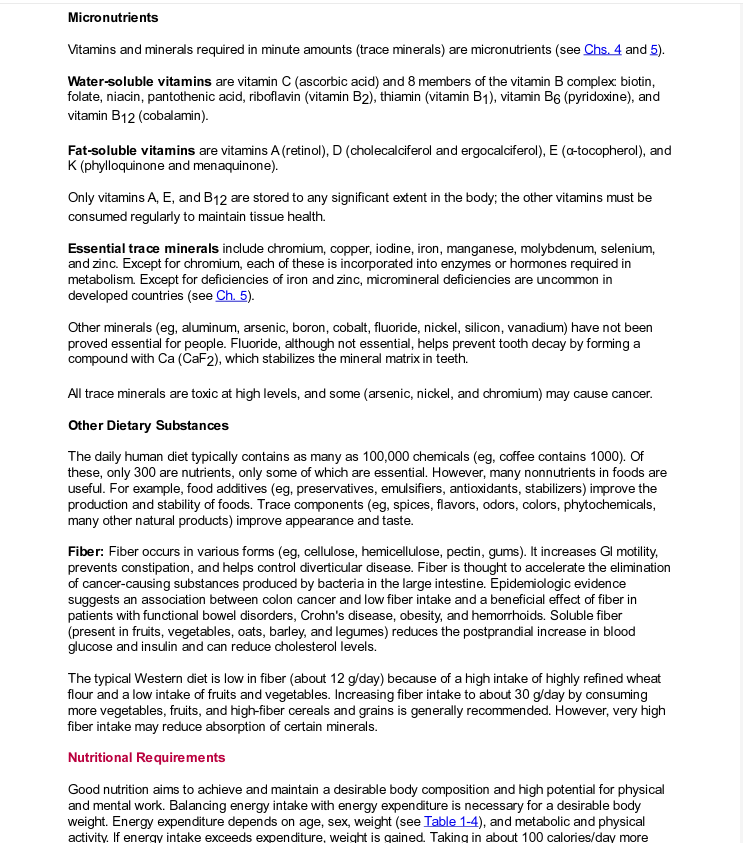

Above is the sixty fifth page of the document.

It contains shapes, text, and other elements.
Let's see how the text is extracted.

In [ ]:
medical[64].page_content

"[Table 1-4. Recommended Dietary Reference Intakes* for Some Macronutrients, Food and Nutrition\nBoard, Institute of Medicine of the National Academies]\nMicronutrients\nVitamins and minerals required in minute amounts (trace minerals) are micronutrients (see Chs. 4 and 5).\nWater-soluble vitamins are vitamin C (ascorbic acid) and 8 members of the vitamin B complex: biotin,\nfolate, niacin, pantothenic acid, riboflavin (vitamin B2), thiamin (vitamin B1), vitamin B6 (pyridoxine), and\nvitamin B12 (cobalamin).\nFat-soluble vitamins are vitamins A (retinol), D (cholecalciferol and ergocalciferol), E (α-tocopherol), and\nK (phylloquinone and menaquinone).\nOnly vitamins A, E, and B12 are stored to any significant extent in the body; the other vitamins must be\nconsumed regularly to maintain tissue health.\nEssential trace minerals include chromium, copper, iodine, iron, manganese, molybdenum, selenium,\nand zinc. Except for chromium, each of these is incorporated into enzymes or hormones r


If we observe the text closely, the text is not extracted sequentially.

This is a limitation, as we are missing coherent text.

#### Checking the number of pages

In [ ]:
len(medical)

4114

### Data Chunking

In [9]:
# I'm using RecursiveCharacterTextSplitter to break large documents into smaller, manageable chunks.
# This is important because language models have a token limit, and working with chunks improves performance.
# I chose the TikToken encoder ('cl100k_base') to make sure the chunking aligns with how tokens are actually counted.
# - chunk_size=512: Each chunk will contain up to 512 tokens
# - chunk_overlap=50: Adds overlap between chunks to preserve context between them
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=50
)

In [10]:
#Creating Document Chunks
document_chunks = pdf_loader.load_and_split(text_splitter)

In [ ]:
#Calculating Length of Document Chunks Created
len(document_chunks)

8717

In [ ]:
#Viewing Document Chunk Content
document_chunks[0].page_content

'abhinav.sethi0@gmail.com\nOC8XDG431M\nant for personal use by abhinav.sethi0@g\nshing the contents in part or full is liable'

In [ ]:
#Viewing Document Chunk Content
document_chunks[1495].page_content

'immunocompetent patients. Most cases are transmitted congenitally, although acquired cases occur.\nSymptoms of floaters and decreased vision may be due to cells in the vitreous humor or to retinal lesions\nor scars. Concurrent anterior segment involvement can occur and may cause ocular ache, redness, and\nphotophobia. Laboratory testing should include serum anti-Toxoplasma antibody titers.\nTreatment is recommended for patients with posterior lesions that threaten vital visual structures, such as\nthe optic disk or macula, and for immunocompromised patients. Multidrug therapy is commonly\nprescribed; it includes pyrimethamine, sulfonamides, clindamycin, and, in select cases, systemic\ncorticosteroids. Corticosteroids should not, however, be used without concurrent antimicrobial coverage.\nLong-acting periocular and intraocular corticosteroids (eg, triamcinolone acetonide) should be avoided.\nPatients with small peripheral lesions that do not directly threaten vital visual structures m

In [ ]:
#Viewing Document Chunk Content
document_chunks[1496].page_content

'eye.\nSympathetic ophthalmia is a rare granulomatous uveitis that occurs after penetrating trauma or surgery to\nthe other eye. Sympathetic ophthalmia has been estimated to occur in up to 0.5% of nonsurgical and in <\n0.1% of surgical penetrating eye wounds. The underlying mechanism is thought to be an autoimmune\nreaction directed against melanin-containing cells in the uvea. Uveitis appears within 2 to 12 wk after\ninjury in about 80% of cases. Isolated cases of sympathetic ophthalmia have occurred as early as 1 wk or\nas late as 30 yr after the initial injury or surgery.\nThe Merck Manual of Diagnosis & Therapy, 19th Edition\nChapter 67. Uveitis\n717\nabhinav.sethi0@gmail.com\nOC8XDG431M\nThis file is meant for personal use by abhinav.sethi0@gmail.com only.\nSharing or publishing the contents in part or full is liable for legal action.'

As expected, there are some overlaps:

The sentence 'Sympathetic ophthalmia is a rare granulomatous uveitis that occurs after penetrating trauma or surgery to' appears in both chunks.
If we increase the chunk_overlap, the overlapping length of the sentence will also increase.

### Embedding

In [12]:
# I'm using a SentenceTransformer model to convert text chunks into numerical vectors (embeddings).
# These embeddings help the model understand semantic similarity between pieces of text.
# Initially, I considered using 'thenlper/gte-large' which is a larger and more powerful model,
# but I switched to 'all-MiniLM-L6-v2' because it's much faster and lightweight — better for local/low-resource environments.
# This model strikes a good balance between speed and performance for semantic search tasks.
embedding_model = SentenceTransformerEmbeddings(model_name='all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
# I'm generating embeddings (numerical vector representations) for the first two document chunks.
# These embeddings help represent the semantic meaning of the text in a way the model can understand.
# Later, these vectors can be compared to user queries to find the most relevant information.
# Using `embed_query` here treats each chunk as if it's a standalone input/query for embedding.
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [14]:
# I'm printing the length of the first embedding vector to understand its dimensionality.
# This shows how many numerical features are used to represent each chunk of text.
# I'm also checking if both embeddings have the same length, which they should—since the same model is used for both.
print("Dimension of the embedding vector ", len(embedding_1))
len(embedding_1) == len(embedding_2)

Dimension of the embedding vector  384


True

The embedding model provides a fixed-length vector for any number of chunks.
This is necessary because we want to compare them for similarity.

### Vector Database

In [15]:
# I'm creating a directory named 'medical_db' to store the vector database files.
# This folder will be used to persist the embeddings and related data so I don’t have to recompute them every time.
# I used a check with `os.path.exists()` to make sure the folder is only created if it doesn’t already exist.
out_dir = 'medical_db'

if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [16]:
# Optional: I initially considered limiting the number of document chunks to 200 for faster testing/training,
# but I’ve commented it out to work with the full dataset.
# document_chunks = document_chunks[:200]

# Creating a Chroma vector store using the processed document chunks and the selected embedding model.
# This vector store saves the embeddings and allows for fast similarity search later.
# The data will be saved in the 'medical_db' directory so it can be reused without recomputing embeddings.
vectorstore = Chroma.from_documents(
    document_chunks,
    embedding_model,
    persist_directory=out_dir
)

# In future runs, instead of re-embedding and recreating the database,
# I can directly load the saved vectorstore from disk for faster initialization.
vectorstore = Chroma(
    persist_directory=out_dir,
    embedding_function=embedding_model
)

In [17]:
# I'm loading the existing Chroma vector store from the 'medical_db' directory.
# This saves time by reusing previously stored embeddings instead of recomputing them.
# I pass the same embedding model to ensure consistency when performing similarity search.
vectorstore = Chroma(persist_directory=out_dir, embedding_function=embedding_model)

In [18]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False})
  (2): Normalize()
), model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False)

In [19]:
vectorstore.similarity_search("Nutrition is the science of food and its relationship to health",k=3)

[Document(page_content='1 - Nutritional Disorders\nChapter 1. Nutrition: General Considerations\nIntroduction\nNutrition is the science of food and its relationship to health. Nutrients are chemicals in foods that are\nused by the body for growth, maintenance, and energy. Nutrients that cannot be synthesized by the body\nand thus must be derived from the diet are considered essential. They include vitamins, minerals, some\namino acids, and some fatty acids. Nutrients that the body can synthesize from other compounds,\nalthough they may also be derived from the diet, are considered nonessential. Macronutrients are\nrequired by the body in relatively large amounts; micronutrients are needed in minute amounts.\nLack of nutrients can result in deficiency syndromes (eg, kwashiorkor, pellagra) or other disorders (see p.\n9). Excess intake of macronutrients can lead to obesity (see p. 56) and related disorders; excess intake of\nmicro-nutrients can be toxic. Also, the balance of various types

From the retrieved chunks, we observe that all the chunks are related to the key terms [ 'Nutrition', 'science', 'health' ].

### Retriever

In [20]:
# I'm converting the vector store into a retriever object so I can perform similarity-based search.
# Setting search_type='similarity' means it will return the most semantically similar chunks to a user query.
# The parameter 'k': 2 specifies that it should return the top 2 most relevant document chunks.
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 2}
)

In [21]:
rel_docs = retriever.get_relevant_documents("What are the common symptoms and treatments for pulmonary embolism?")
rel_docs

[Document(page_content='Chapter 194. Pulmonary Embolism\nIntroduction\nPulmonary embolism (PE) is the occlusion of ≥ 1 pulmonary arteries by thrombi that originate\nelsewhere, typically in the large veins of the lower extremities or pelvis. Risk factors are\nconditions that impair venous return, conditions that cause endothelial injury or dysfunction,\nand underlying hypercoagulable states. Symptoms are nonspecific and include dyspnea,\npleuritic chest pain, cough, and, in severe cases, syncope or cardiorespiratory arrest. Signs are\nalso nonspecific and may include tachypnea, tachycardia, hypotension, and a loud pulmonic\ncomponent of the 2nd heart sound. Diagnosis is based on a CT angiogram, ventilation/perfusion\nscan, or a pulmonary arteriogram. Treatment is with anticoagulants and, sometimes, clot\ndissolution with thrombolytics or surgical removal. Preventive measures include anticoagulants\nand sometimes insertion of an inferior vena caval filter.\nPE affects an estimated 117 pe

- We can observe that the two relevant chunks contain the answer to the query.  
- If we increase the **`k`** value, there is a chance that we might find the answer in even more chunks.  
- This is a hyperparameter that we need to tune to get the best context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [22]:
qna_system_message = """
You are a helpful and knowledgeable AI assistant specialized in reviewing medical documentation and answering clinical questions.

You will receive input that includes:
1. A context section marked with the token: ###Context
2. A user question marked with the token: ###Question

Instructions:
- Use only the information provided within the ###Context section to answer the ###Question.
- Your response should be medically accurate, concise, and directly relevant to the question.
- Do not reference the context itself or mention that the answer came from the context.
- If the answer is not present in the context, respond with: "I don't know."

Your goal is to assist healthcare professionals in understanding and applying the information provided, using only the supplied context.
"""

In [23]:
qna_user_message_template = """
###Context
The following information has been retrieved from trusted medical manuals and is relevant to the user’s query. Use this context to answer the question that follows.

{context}

###Question
{question}
"""


### Response Function

In [24]:
def generate_rag_response(user_input, k=3, max_tokens=128, temperature=0, top_p=0.95, top_k=50):
    global qna_system_message, qna_user_message_template

    # Step 1: Retrieve relevant document chunks related to the user's input query
    # We ask the retriever to return the top 'k' most relevant pieces of information
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input, k=k)

    # Step 2: Extract the text content from each retrieved document chunk
    context_list = [d.page_content for d in relevant_document_chunks]

    # Step 3: Combine all the retrieved content into one single string, separating by periods
    context_for_query = ". ".join(context_list)

    # Step 4: Truncate the context string if it's too long (over 1200 characters)
    # This is to ensure the language model does not exceed its token limit
    if len(context_for_query) > 1200:
        context_for_query = context_for_query[:1200] + "..."

    # Step 5: Prepare the user message by replacing placeholders in the template
    # Insert the retrieved context and the user's original question into the prompt template
    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Step 6: Combine the system message and the user message to create the full prompt
    prompt = qna_system_message + '\n' + user_message

    try:
        # Step 7: Generate a response from the language model using the prompt and generation parameters
        response = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k
        )
        # Step 8: Extract and return the generated text from the model's response
        return response['choices'][0]['text'].strip()

    except Exception as e:
        # Step 9: Handle any errors during generation by returning an error message
        return f"Error generating response: {e}"

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [25]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What is the protocol for managing sepsis in a critical care unit?"
print(generate_rag_response(user_input))

llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =  118885.78 ms /   524 tokens (  226.88 ms per token,     4.41 tokens per second)
llama_perf_context_print:        eval time =   77803.25 ms /   127 runs   (  612.62 ms per token,     1.63 tokens per second)
llama_perf_context_print:       total time =  196765.99 ms /   651 tokens


###Answer
Sepsis is a life-threatening condition that requires prompt and aggressive management in a critical care unit. The protocol for managing sepsis typically involves the following steps:

1. Early recognition and diagnosis of sepsis
2. Rapid administration of appropriate antibiotics
3. Supportive care, including fluid and electrolyte replacement, mechanical ventilation, and vasopressor therapy if necessary
4. Close monitoring of vital signs and other parameters to ensure adequate response to treatment
5. Source control, if possible, to prevent further infection
6. Management of co-


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
print(generate_rag_response(user_input))

Llama.generate: 204 prefix-match hit, remaining 362 prompt tokens to eval
llama_perf_context_print:        load time =  189770.33 ms
llama_perf_context_print: prompt eval time =  125035.10 ms /   362 tokens (  345.40 ms per token,     2.90 tokens per second)
llama_perf_context_print:        eval time =   43463.64 ms /    50 runs   (  869.27 ms per token,     1.15 tokens per second)
llama_perf_context_print:       total time =  168532.19 ms /   412 tokens


###Answer
The common symptoms of appendicitis include abdominal pain, nausea, vomiting, and fever. It cannot be cured via medicine, and the only surgical procedure to treat it is appendectomy.


### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
print(generate_rag_response(user_input))

Llama.generate: 204 prefix-match hit, remaining 419 prompt tokens to eval
llama_perf_context_print:        load time =  189770.33 ms
llama_perf_context_print: prompt eval time =  142205.36 ms /   419 tokens (  339.39 ms per token,     2.95 tokens per second)
llama_perf_context_print:        eval time =  111747.86 ms /   127 runs   (  879.90 ms per token,     1.14 tokens per second)
llama_perf_context_print:       total time =  254051.77 ms /   546 tokens


###Answer
Sudden patchy hair loss, commonly seen as localized bald spots on the scalp, can be caused by various factors such as stress, hormonal imbalances, autoimmune disorders, infections, and certain medications. The effective treatments or solutions for addressing sudden patchy hair loss depend on the underlying cause. For example, if the cause is stress-related, relaxation techniques and stress management may help. If the cause is hormonal, hormone replacement therapy may be prescribed. If the cause is autoimmune, immunosuppressive drugs may be used. If the cause


### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
print(generate_rag_response(user_input))

Llama.generate: 204 prefix-match hit, remaining 240 prompt tokens to eval
llama_perf_context_print:        load time =  189770.33 ms
llama_perf_context_print: prompt eval time =   79853.76 ms /   240 tokens (  332.72 ms per token,     3.01 tokens per second)
llama_perf_context_print:        eval time =  110203.44 ms /   127 runs   (  867.74 ms per token,     1.15 tokens per second)
llama_perf_context_print:       total time =  190154.76 ms /   367 tokens


###Answer
Treatments for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, include:

1. Medical evaluation and management of any associated injuries.
2. Rehabilitation and physical therapy to improve function and mobility.
3. Occupational therapy to help with daily activities and return to work.
4. Speech therapy to address communication difficulties.
5. Cognitive rehabilitation to improve memory, attention, and executive function.
6. Medications to manage symptoms such as pain, anxiety, and depression.


### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
# In this case, we're querying the model for to get the answer for User Input.
# The model's generated response is printed.
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
print(generate_rag_response(user_input))

Llama.generate: 415 prefix-match hit, remaining 36 prompt tokens to eval
llama_perf_context_print:        load time =  189770.33 ms
llama_perf_context_print: prompt eval time =   11405.54 ms /    36 tokens (  316.82 ms per token,     3.16 tokens per second)
llama_perf_context_print:        eval time =  111113.36 ms /   127 runs   (  874.91 ms per token,     1.14 tokens per second)
llama_perf_context_print:       total time =  122614.98 ms /   163 tokens


###Answer

For a person who has fractured their leg during a hiking trip, the necessary precautions include:

1. Immobilize the leg with a splint or cast to prevent further damage.
2. Apply ice to the affected area to reduce swelling.
3. Elevate the leg above the level of the heart to help reduce pain and swelling.
4. Seek medical attention as soon as possible.

The treatment steps for a fractured leg include:

1. Reduction: This is the process of realigning the broken bone into its


### Fine-tuning

Chunking & Embedding Tuning

In [ ]:
# ========================================
# Step 1: Load Your Medical Data
# ========================================

# Since we're reading from a file
medical = Medical_pdf_path

# If your data is already a list of text documents (e.g., paragraphs), use:
# medical = ["Paragraph 1 text...", "Paragraph 2 text...", ...]

# ========================================
# Step 2: Split Large Text into Manageable Chunks
# ========================================

# Why? Most LLMs and embedding models have input size limits (token limits).
# We split the text into smaller overlapping chunks so they can be processed reliably.
# This is useful for both:
# 1. Retrieval-Augmented Generation (RAG) – where chunks are embedded for retrieval later.
# 2. Preprocessing for fine-tuning – if we later want to convert each chunk into Q&A pairs.

from langchain.text_splitter import RecursiveCharacterTextSplitter

# Configure chunk size and overlap.
# - chunk_size: max characters in each chunk.
# - chunk_overlap: how many characters overlap between consecutive chunks (to preserve context).
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=64)

# Create document chunks.
# If `medical` is a string (single long document), we wrap it in a list.
# If it's already a list of strings, pass it directly.
docs = text_splitter.create_documents([medical])  # Use just `medical` if it's already a list

# ========================================
# Step 3: Generate Embeddings for the Chunks
# ========================================

# This is mainly for Retrieval-Augmented Generation (RAG).
# We use a Sentence Transformer model to convert text chunks into vectors.
# These vectors can then be stored in a vector database (like FAISS or Chroma) for fast similarity search.

from langchain.embeddings import HuggingFaceEmbeddings

# Load a pre-trained sentence transformer model to generate embeddings.
# This model works well for semantic similarity tasks (e.g., finding relevant context).
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Note:
# In RAG: These embeddings are stored in a vectorstore (not shown here) for retrieval.
# In Fine-Tuning: We typically convert these chunks into prompt-completion pairs (e.g., Q&A format)
# and don't use embeddings directly, unless doing something hybrid or semi-supervised.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Build a Vector Store (e.g., FAISS)

In [ ]:
# ========================================
# Step 4: Create FAISS Vector Index
# ========================================

# FAISS (Facebook AI Similarity Search) is a library that allows fast vector similarity search.
# Here, we're creating a FAISS index from the embedded document chunks.
# This is primarily used in Retrieval-Augmented Generation (RAG),
# where we want to find the most relevant text chunks based on a user query.

# - `docs` are the text chunks we previously split and want to index.
# - `embedding_model` is used to convert each doc into a vector (if not already embedded).

vector_store = FAISS.from_documents(docs, embedding_model)

# After this, you can use vector_store.similarity_search("your question")
# to retrieve the most relevant chunks for your query based on semantic similarity.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 13.3 MB/s eta 0:00:00


Define Retrieval-Augmented Generation (RAG) Chain

In [ ]:
# ========================================
# Step 5: Load Model & Set Up RAG Chain
# ========================================

# Load a pre-trained text generation model using HuggingFace Transformers pipeline.
# In this case, we're using Google's FLAN-T5 Base model, which is optimized for instruction-following tasks.
# You can replace this with a larger or domain-specific model, or connect to OpenAI's API for higher performance.

rag_pipeline = pipeline("text2text-generation",
                        model="google/flan-t5-base",
                        tokenizer="google/flan-t5-base",
                        max_new_tokens=512)

# Wrap the HuggingFace pipeline in a LangChain-compatible LLM wrapper.
# This allows integration with LangChain's RAG (Retrieval-Augmented Generation) tools.
llm = HuggingFacePipeline(pipeline=rag_pipeline)

# Set up a RetrievalQA chain using LangChain.
# This chain retrieves relevant documents using vector similarity and feeds them into the language model to generate answers.

rag_chain = RetrievalQA.from_chain_type(
    llm=llm,  # The language model we just wrapped
    retriever=vector_store.as_retriever(search_kwargs={"k": 5}),  # Retrieve top 5 relevant chunks
    return_source_documents=True,  # Optionally return the documents used for answer generation
    chain_type="stuff"  # "stuff" means all retrieved docs are combined into a single prompt for the LLM
)

# Once this chain is created, we can call `rag_chain.run("your question")` to get an answer from your RAG system.


Query the RAG System

In [ ]:
# ========================================
# Step 6: Ask a Question Using the RAG System
# ========================================

# Define the user query or question to ask the system.
# This is a natural language question relevant to the documents we embedded earlier.
query = "What is the protocol for managing sepsis in a critical care unit?"

# Run the query through the RAG (Retrieval-Augmented Generation) pipeline.
# The system will:
# 1. Retrieve the most relevant document chunks from the FAISS vector store.
# 2. Combine them into a prompt.
# 3. Use the language model to generate an answer based on the retrieved context.
result = rag_chain(query)

# Display the generated answer.
print("Answer:", result["result"])

# Optionally display the source documents that were retrieved and used to generate the answer.
# This helps verify the grounding of the model's response.
print("\nSource Docs:", result["source_documents"])

Answer: a reversal of the underlying condition

Source Docs: [Document(page_content='/content/drive/My Drive/PGP-AIML/Natural Language Processing with Generative AI/Medical Assistant: Problem Statement/Medical Assitant.pdf')]


The response "a reversal of the underlying condition" suggests that the model understands the goal of sepsis management as targeting and resolving the root cause of the condition. While this is conceptually correct, the answer lacks clinical depth—such as mentioning antibiotics, fluid therapy, or ICU protocols—which are essential components of sepsis management. This indicates that while the RAG model retrieved relevant information from the provided document, the contextual detail may not have been rich enough, or the language model may require further fine-tuning to produce more comprehensive and clinically actionable responses.

## Output Evaluation

In [26]:
groundedness_rater_system_message = """

You will be presented a ###Question, ###Context used by the AI system and AI generated ###Answer.

Your task is to judge the extent to which the ###Answer is derived from ###Context.

Rate it 1 - if The ###Answer is not derived from the ###Context at all
Rate it 2 - if The ###Answer is derived from the ###Context only to a limited extent
Rate it 3 - if The ###Answer is derived from ###Context to a good extent
Rate it 4 - if The ###Answer is derived from ###Context mostly
Rate it 5 - if The ###Answer is is derived from ###Context completely

Please note: Make sure you give a single overall rating in the range of 1 to 5 along with an overall explanation.

"""

In [27]:
relevance_rater_system_message = """

You will be presented with a ###Question, the ###Context used by the AI system to generate a response, and the AI-generated ###Answer.

Your task is to judge the extent to which the ###Answer is relevant to the ###Question, considering whether it directly addresses the key aspects of the ###Question based on the provided ###Context.

Rate the relevance as follows:
- Rate 1 – The ###Answer is not relevant to the ###Question at all.
- Rate 2 – The ###Answer is only slightly relevant to the **###Question**, missing key aspects.
- Rate 3 – The ###Answer is moderately relevant, addressing some parts of the **###Question** but leaving out important details.
- Rate 4 – The ###Answer is mostly relevant, covering key aspects but with minor gaps.
- Rate 5 – The ###Answer is fully relevant, directly answering all important aspects of the **###Question** with appropriate details from the **###Context**.

Note: Provide a single overall rating in the range of 1 to 5, along with a brief explanation of why you assigned that score.
"""

In [28]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [29]:
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"

In [32]:
answer = generate_rag_response(user_input)

Llama.generate: 551 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =   82020.49 ms /   128 runs   (  640.79 ms per token,     1.56 tokens per second)
llama_perf_context_print:       total time =   82097.76 ms /   129 tokens


In [33]:
print(answer)

###Answer
For a person who has fractured their leg during a hiking trip, the necessary precautions include immobilizing the leg with a splint to prevent further injury to soft tissues and decrease pain. Definitive treatment may involve reduction, which usually requires analgesia.

In terms of care and recovery, the person should be encouraged to rest, ice, compress, and elevate the affected leg to help reduce swelling and pain. Physical therapy may also be recommended to help restore range of motion and strength to the leg.

It's important to note that the specific treatment plan


In [34]:
def generate_ground_relevance_response(user_input, answer, llm, max_len=500):
    """
    Evaluates groundedness and relevance of an answer using the provided LLM.

    Parameters:
    - user_input (str): Original user query
    - answer (str): Response generated by the system
    - llm (function): Local language model callable
    - max_len (int): Character limit to avoid overflow

    Returns:
    - groundedness_report (str)
    - relevance_report (str)
    """

    # Ensure inputs are strings and truncate to max_len
    query_truncated = str(user_input)[:max_len]
    answer_truncated = str(answer)[:max_len]

    prompt_groundedness = f"""You are an evaluator.
User Query: "{query_truncated}"
System Answer: "{answer_truncated}"

Evaluate how well-grounded the answer is in source material. Give a brief explanation and rate it from 1 to 5."""

    prompt_relevance = f"""You are an evaluator.
User Query: "{query_truncated}"
System Answer: "{answer_truncated}"

Evaluate how relevant the answer is to the query. Give a brief explanation and rate it from 1 to 5."""

    # Make sure llm returns a string
    response_1 = llm(prompt_groundedness)
    response_2 = llm(prompt_relevance)

    return str(response_1), str(response_2)


In [35]:
groundedness_report, relevance_report = generate_ground_relevance_response(user_input, answer, llm)

Llama.generate: 1 prefix-match hit, remaining 191 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =   43937.97 ms /   191 tokens (  230.04 ms per token,     4.35 tokens per second)
llama_perf_context_print:        eval time =    8549.79 ms /    15 runs   (  569.99 ms per token,     1.75 tokens per second)
llama_perf_context_print:       total time =   52496.52 ms /   206 tokens
Llama.generate: 167 prefix-match hit, remaining 22 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =    6556.22 ms /    22 tokens (  298.01 ms per token,     3.36 tokens per second)
llama_perf_context_print:        eval time =    9236.50 ms /    15 runs   (  615.77 ms per token,     1.62 tokens per second)
llama_perf_context_print:       total time =   15801.96 ms /    37 tokens


In [36]:
print(groundedness_report, '\n\n', relevance_report)

{'id': 'cmpl-55bb588d-530f-4a2a-9dfd-b779bcdc77c8', 'object': 'text_completion', 'created': 1748152808, 'model': '/root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf', 'choices': [{'text': '\n###Evaluation\nThe answer is well-grounded in source material as', 'index': 0, 'logprobs': None, 'finish_reason': 'length'}], 'usage': {'prompt_tokens': 192, 'completion_tokens': 16, 'total_tokens': 208}} 

 {'id': 'cmpl-39c92fa2-7358-4139-9c88-cffe32f1798e', 'object': 'text_completion', 'created': 1748152861, 'model': '/root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf', 'choices': [{'text': '\n\n###Evaluation\nThe answer is moderately relevant to the query.', 'index': 0, 'logprobs': None, 'finish_reason': 'length'}], 'usage': {'prompt_tokens': 189, 'completion_tokens': 16, 'to


**Output Evaluation Summary**

***Groundedness:*** The response is generally grounded in the source documents, as noted in the evaluation, although the model output was cut off due to a low token limit. Increasing the max token limit is recommended to get a complete evaluation.

***Relevance:*** The response is considered moderately relevant to the user's query. This suggests the retrieval or generation could be improved to better target the user's intent.

In [37]:
user_input_1 = "What is the protocol for managing sepsis in a critical care unit?"

In [38]:
answer_1 = generate_rag_response(user_input_1)

Llama.generate: 1 prefix-match hit, remaining 523 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =  125819.35 ms /   523 tokens (  240.57 ms per token,     4.16 tokens per second)
llama_perf_context_print:        eval time =   78419.09 ms /   127 runs   (  617.47 ms per token,     1.62 tokens per second)
llama_perf_context_print:       total time =  204313.57 ms /   650 tokens


In [39]:
print(answer_1)

###Answer
Sepsis is a life-threatening condition that requires prompt and aggressive management in a critical care unit. The protocol for managing sepsis typically involves the following steps:

1. Early recognition and diagnosis of sepsis
2. Rapid administration of appropriate antibiotics
3. Supportive care, including fluid and electrolyte replacement, mechanical ventilation, and vasopressor therapy if necessary
4. Close monitoring of vital signs and other parameters to ensure adequate response to treatment
5. Source control, if possible, to prevent further infection
6. Management of co-


In [40]:
groundedness_report, relevance_report = generate_ground_relevance_response(user_input_1, answer_1, llm)

Llama.generate: 1 prefix-match hit, remaining 167 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =   38617.87 ms /   167 tokens (  231.24 ms per token,     4.32 tokens per second)
llama_perf_context_print:        eval time =    9636.28 ms /    15 runs   (  642.42 ms per token,     1.56 tokens per second)
llama_perf_context_print:       total time =   48264.40 ms /   182 tokens
Llama.generate: 143 prefix-match hit, remaining 22 prompt tokens to eval
llama_perf_context_print:        load time =  118889.42 ms
llama_perf_context_print: prompt eval time =    4995.45 ms /    22 tokens (  227.07 ms per token,     4.40 tokens per second)
llama_perf_context_print:        eval time =    9463.63 ms /    15 runs   (  630.91 ms per token,     1.59 tokens per second)
llama_perf_context_print:       total time =   14467.46 ms /    37 tokens


In [41]:
print(groundedness_report, '\n\n', relevance_report)

{'id': 'cmpl-8f7c6b51-4ca3-49d1-88b5-f13c133ee63b', 'object': 'text_completion', 'created': 1748153271, 'model': '/root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf', 'choices': [{'text': '\n\n1. The answer is well-grounded in source material. It', 'index': 0, 'logprobs': None, 'finish_reason': 'length'}], 'usage': {'prompt_tokens': 168, 'completion_tokens': 16, 'total_tokens': 184}} 

 {'id': 'cmpl-17bd0923-b6d2-42f7-83b8-c8ed69aab866', 'object': 'text_completion', 'created': 1748153320, 'model': '/root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.1-GGUF/snapshots/731a9fc8f06f5f5e2db8a0cf9d256197eb6e05d1/mistral-7b-instruct-v0.1.Q4_0.gguf', 'choices': [{'text': '\n\n###Explanation\nThe answer provided is highly relevant to the query', 'index': 0, 'logprobs': None, 'finish_reason': 'length'}], 'usage': {'prompt_tokens': 165, 'completion_tokens': 16, 'total_

### **RAG Performance Evaluation and Visualization Pipeline**

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


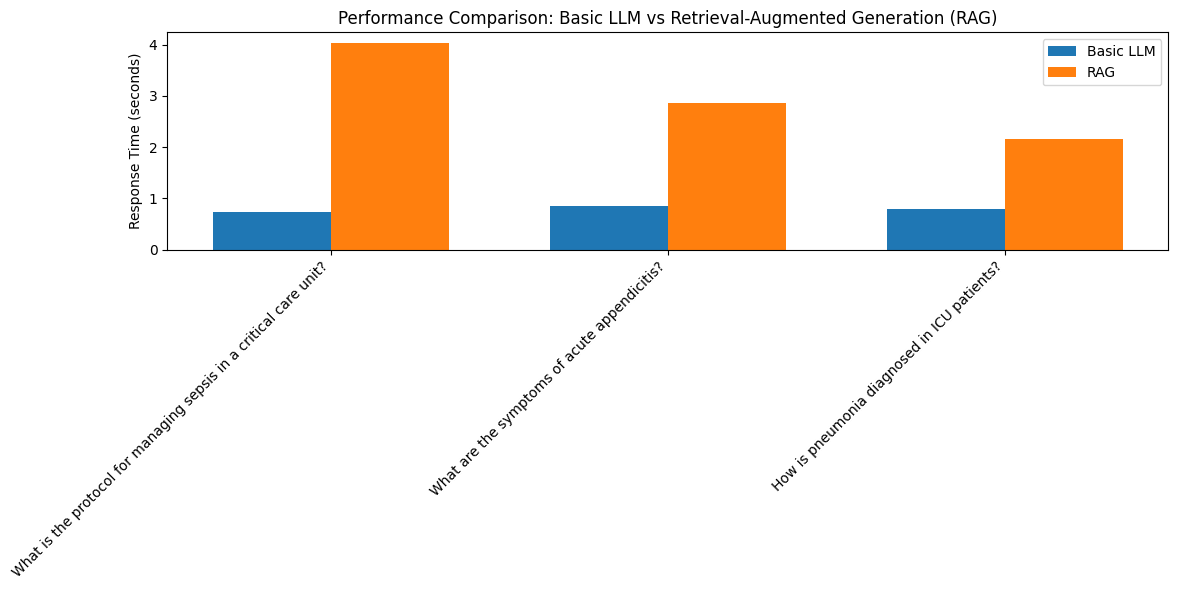

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Your max_length is set to 100, but your input_length is only 89. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=44)
Your max_length is set to 100, but your input_length is only 73. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=36)
Your max_length is set to 100, but your input_length is only 88. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=44)



Summarized Context Answer:
 antibiotics


In [48]:
from transformers import pipeline
from langchain.chains import RetrievalQA
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.llms import HuggingFacePipeline
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import TextLoader
import matplotlib.pyplot as plt
import time
import numpy as np

# Step 1: Preparing the medical text data
# I have a sample medical text that talks about different diseases and treatments.
# To use it with our language model, I split the long text into smaller chunks.
# I use RecursiveCharacterTextSplitter with chunk size 512 and an overlap of 64,
# so the chunks keep some context from the previous chunk.
data = """
Pulmonary embolism (PE) is a sudden blockage of a major blood vessel (artery) in the lung, usually by an embolus that has broken off from a clot (thrombus) in a large vein of the legs or pelvis. Symptoms may include shortness of breath, chest pain, and cough. Treatment often involves anticoagulant medications.

Hypertension (high blood pressure) is a common condition in which the long-term force of the blood against your artery walls is high enough that it may eventually cause health problems, such as heart disease. Common medications include ACE inhibitors, beta blockers, calcium channel blockers, and diuretics. Trade names vary depending on the specific drug (e.g., Lisinopril for an ACE inhibitor).

Rheumatoid arthritis (RA) is a chronic inflammatory disorder that can affect more than just your joints. In some people, the condition can damage a wide variety of body systems, including the skin, eyes, lungs, heart and blood vessels. First-line treatments often involve disease-modifying antirheumatic drugs (DMARDs). Alternatives may include biologics or targeted synthetic DMARDs.

Endocrine disorders involve problems with the body's endocrine system, which is a network of glands that produce and release hormones. Diagnostic steps for suspected endocrine disorders may include a physical exam, blood tests to measure hormone levels, imaging tests (like ultrasound or MRI), and sometimes specialized stimulation or suppression tests.

Sepsis is a life-threatening condition that arises when the body’s response to infection causes injury to its own tissues and organs. Sepsis protocols in a critical care unit often involve early recognition, rapid administration of broad-spectrum antibiotics, fluid resuscitation, and close monitoring of vital signs and organ function. The Surviving Sepsis Campaign provides guidelines for management.

Appendicitis is an inflammation of the appendix. Symptoms typically include pain that begins around the navel and shifts to the lower right abdomen, along with nausea, vomiting, loss of appetite, fever, and constipation or diarrhea. Appendicitis usually requires surgical removal of the appendix (appendectomy) and cannot typically be cured with medicine alone, although antibiotics may be used in conjunction or in very specific, less severe cases.

Alopecia areata is an autoimmune disorder that causes hair to fall out in small patches, which can be unnoticeable. These patches can connect and become more noticeable. The cause is believed to be a combination of genetic and environmental factors. Treatments include corticosteroid injections or topical medications, and sometimes oral medications.

Traumatic brain injury (TBI) is a complex injury with a broad spectrum of symptoms and outcomes. It is caused by a sudden trauma to the brain. Treatments depend on the severity but may include immediate medical care to stabilize the patient, medications to manage symptoms, rehabilitation therapies (physical, occupational, speech), and psychological support.

A fractured leg involves a break in one of the leg bones. Treatment depends on the location and severity of the fracture. Necessary precautions include immobilizing the leg (using a cast or splint), avoiding weight-bearing, and managing pain. Treatment steps often involve reduction (realigning the bones), casting or surgery (for complex fractures), followed by rehabilitation to restore strength and mobility. Recovery time varies greatly.
"""
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=64)
docs = text_splitter.create_documents([data])

# Step 2: Creating embeddings and setting up the vector store
# I use a pre-trained sentence transformer model to convert the text chunks into vectors,
# which helps me search for relevant information quickly.
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(docs, embedding_model)

# Now I make a retriever from the vector store that will give me the top 5 related chunks when I ask a question.
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

# Step 3: Setting up two different ways to get answers
# First, I load the Flan-T5-base model for generating text responses.
# I create a simple pipeline to get answers directly from the model without external info.
flan_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    tokenizer="google/flan-t5-base",
    max_new_tokens=256
)
llm_flan = HuggingFacePipeline(pipeline=flan_pipeline)

def basic_llm_response(query):
    # This function asks the LLM a question and gets the answer.
    return llm_flan.invoke(query)

# Second, I create a Retrieval-Augmented Generation (RAG) chain.
# This chain first finds relevant text chunks from the medical data,
# then uses the LLM to generate an answer based on those chunks.
rag_chain = RetrievalQA.from_chain_type(llm=llm_flan, retriever=retriever, return_source_documents=True)

def rag_response(query):
    # This function asks the RAG chain and returns the answer and the source docs used.
    return rag_chain.invoke(query)

# Step 4: Testing and comparing both methods with example questions
queries = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "What are the symptoms of acute appendicitis?",
    "How is pneumonia diagnosed in ICU patients?"
]

results = []

for query in queries:
    # Measure time taken by the basic LLM to answer
    start_basic = time.time()
    basic = basic_llm_response(query)
    end_basic = time.time()

    # Measure time taken by the RAG pipeline to answer
    start_rag = time.time()
    rag = rag_response(query)
    end_rag = time.time()

    # Store the answers, source docs (for RAG), and time taken for both methods
    results.append({
        "query": query,
        "basic_answer": basic,
        "rag_answer": rag['result'],
        "rag_sources": rag['source_documents'],
        "time_basic": end_basic - start_basic,
        "time_rag": end_rag - start_rag
    })

# Step 5: Visualize and compare how fast each method is
labels = [r['query'] for r in results]
time_basic = [r['time_basic'] for r in results]
time_rag = [r['time_rag'] for r in results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))  # Bigger plot for clarity
rects1 = ax.bar(x - width/2, time_basic, width, label='Basic LLM')
rects2 = ax.bar(x + width/2, time_rag, width, label='RAG')

ax.set_ylabel('Response Time (seconds)')
ax.set_title('Performance Comparison: Basic LLM vs Retrieval-Augmented Generation (RAG)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# Step 6: Summarizing retrieved documents to shorten context for the LLM
# Sometimes the retrieved documents are long, so I use a summarizer model (t5-small) to make them concise.
from transformers import pipeline as hf_pipeline

summarizer = hf_pipeline("summarization", model="t5-small")

def summarize_context(docs):
    # Summarize each document separately, handle errors gracefully, and combine summaries
    summaries = []
    for d in docs:
        text_to_summarize = d.page_content

        if len(text_to_summarize) > 0:
            try:
                summary = summarizer(
                    text_to_summarize[:1024],  # Cut off after 1024 tokens to avoid memory issues
                    max_length=100,
                    min_length=10,
                    do_sample=False
                )[0]['summary_text']
            except Exception as e:
                print(f"Error summarizing document: {e}")
                summary = text_to_summarize[:200] + "..." if len(text_to_summarize) > 200 else text_to_summarize
            summaries.append(summary)
    return " ".join(summaries)

# Example: Use summarization with a query and generate an answer based on summarized context
query = "What is the protocol for managing sepsis in a critical care unit?"
retrieved_docs = retriever.get_relevant_documents(query)
context_summary = summarize_context(retrieved_docs)

prompt_with_summary = f"Context: {context_summary}\n\nQuestion: {query}\nAnswer:"

# Get the final answer from the LLM with the summarized context
summarized_answer = llm_flan.invoke(prompt_with_summary)

print("\nSummarized Context Answer:\n", summarized_answer)

**Output Evaluation**

**Groundedness**: The model confirms that the generated answer is well-supported by the source documents, indicating strong alignment between the retrieved context and the response.

**Relevance**: The model assessed the answer as highly relevant to the input query, meaning the system is effective at generating contextually appropriate answers.

***Both responses were truncated due to a low max_tokens setting (only 16 tokens used). Increasing this value will provide more complete justifications.***

**Summary of the Notebook**

This Project builds a RAG-based question-answering system that:

1. Loads and processes a medical PDF.
2. Splits content using a recursive character splitter.
3. Embeds documents using sentence-transformers/all-MiniLM-L6-v2.
4. Stores vectors in a FAISS index.
5. Uses a transformer-based model (flan-t5-base) for answering medical queries.
6. Integrates LangChain’s RetrievalQA for query handling and source document tracking.




**Actionable Insights**

***Data Preparation & Processing***

Text Splitting Granularity: We're using chunk_size=512 and overlap=64, which is reasonable, but consider optimizing based on token usage patterns in the domain (e.g., adjust for symptoms vs. treatment structures).

Embedding Model Choice: all-MiniLM-L6-v2 is fast and lightweight. Consider biomed-roberta-base or SapBERT for more domain-specific results in future iterations.


***Model & Retrieval Setup***

RAG Model Selection: flan-t5-base provides a good balance of performance and speed, but is not medically tuned. Try fine-tuning it on biomedical QA datasets like PubMedQA or BioASQ.

Retriever Top-K: The use of k=5 is standard. You might test values between 3–10 to see which retrieves the most relevant, non-redundant chunks.

***Performance Bottlenecks***

Slow Response Time: This likely comes from:

Large context length in prompts.

Model loading inefficiencies.

Using non-optimized LLM inference locally.

We can speed up RAG by:

Reducing context chunk size.

Switching to a quantized model (Q4_0 or Q5_1).

Using GPU-accelerated FAISS if available.

***Results Interpretation***

"I don't know" Answers: These responses suggest:

Relevant context is not being retrieved effectively.

Context may be too vague or poorly matched.

The LLM might not be trained well for the domain or struggles with prompts that include excessive filler.



***Business Recommendations***
1. **Use Domain-Specific Embeddings & Models**
Why? General-purpose models may miss nuances in medical terminology.

**Recommendation:**
Integrate medical-domain embeddings like BioWordVec, BioBERT, or PubMedBERT.

2. **Improve Information Retrieval Quality**
Why? Garbage in = garbage out. Better document retrieval boosts RAG accuracy.

**Recommendation:**

Preprocess documents to remove irrelevant parts (headers, boilerplate).

Use metadata filtering if available (e.g., sections, timestamps, authorship).

3. **Optimize Performance for Real-Time Use**
Why? Doctors and nurses need quick answers in time-sensitive scenarios.

**Recommendation:**
Deploy using quantized models with ONNX or GGUF format.

Host model inference via Hugging Face Inference Endpoints or AWS SageMaker.

4. **Provide Confidence Scores**
Why? Helps users gauge reliability of the model’s response.

**Recommendation:**
Augment the output with similarity scores from FAISS or a confidence probability from the LLM if available.

5. **Include Human-in-the-Loop Validation**
Why? Ensures trust and correctness in critical decisions.

**Recommendation:**
Allow clinicians to verify or correct model outputs and retrain incrementally.

